1. data loading

In [63]:
import pandas as pd
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'your data is successfully loaded {df.shape}')
df.head()

your data is successfully loaded (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


2.understanding the data

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [65]:
#label is target having object data type
#no null values

In [66]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [67]:
# overall crops growing in maximum temperature is 43 and humidity close to 100
# have to understand this potassium , phosphorus  , temp and all for each label (target)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df['label'].nunique()

22

<Axes: xlabel='count', ylabel='label'>

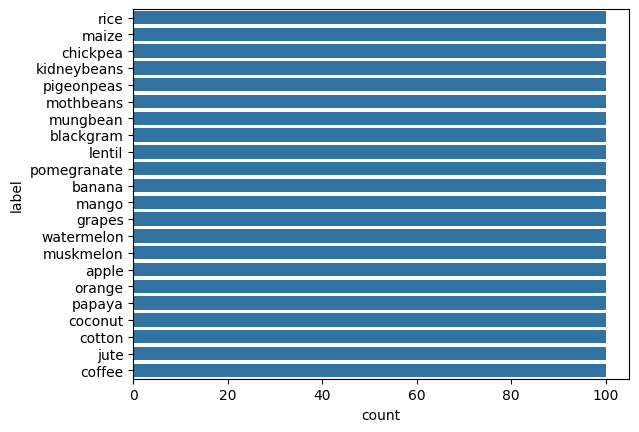

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(df['label'])

In [71]:
X = df.drop(columns='label')
y = df['label']

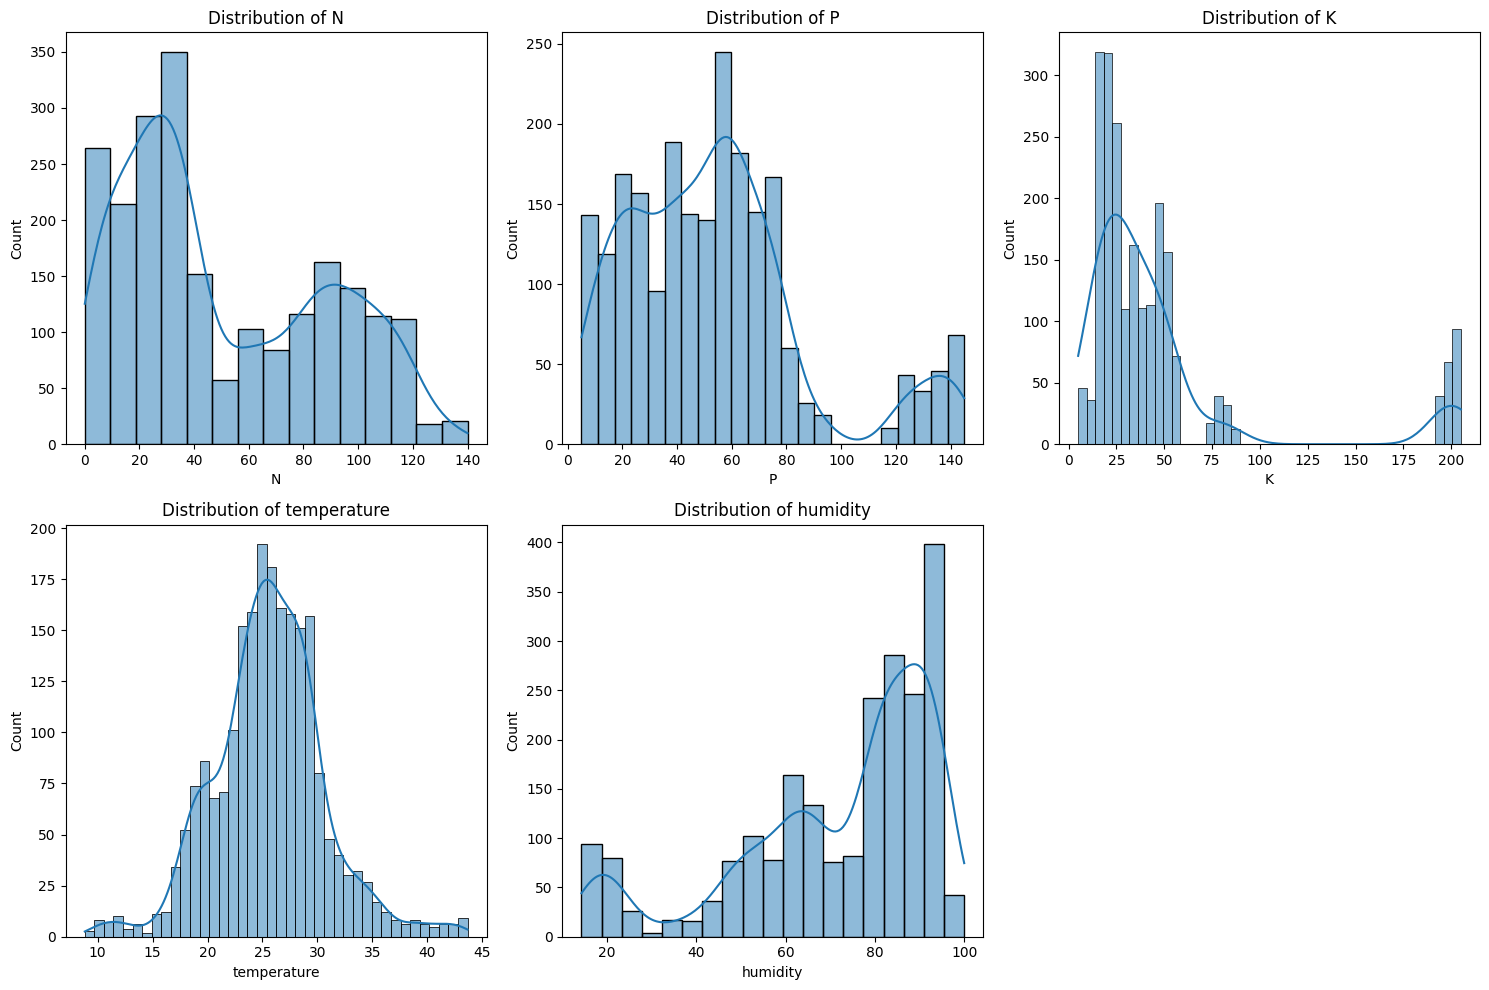

In [72]:
fig , ax = plt.subplots(2,3,figsize=(15,10))
ax = ax.flatten()

for i, col in enumerate(X.columns):
    if i < len(ax):
        sns.histplot(X[col], kde=True, ax=ax[i])
        ax[i].set_title(f'Distribution of {col}')
    else:
        ax[-1].remove()

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

In [73]:
# temperature is like bell shaped graph
# humidity is left skewed and then irregular shape

<Axes: ylabel='label'>

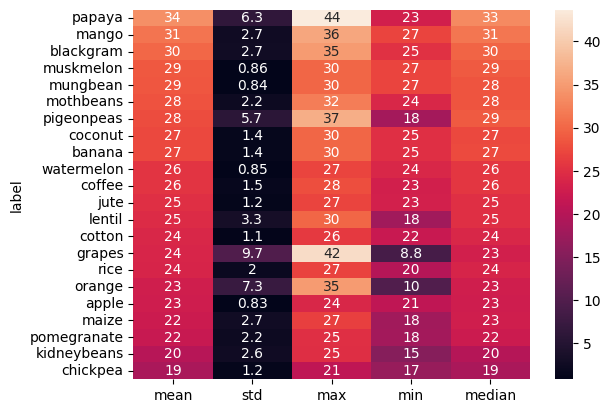

In [74]:
sns.heatmap(df.groupby('label')['temperature'].agg(['mean','std','max','min','median']).sort_values(by='mean',ascending=False),annot=True)

<Axes: ylabel='label'>

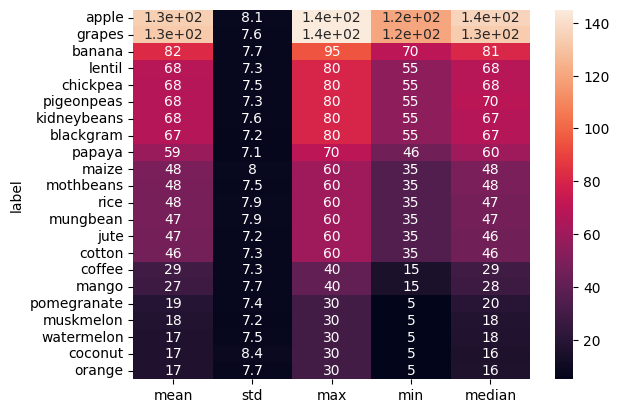

In [75]:
sns.heatmap(df.groupby('label')['P'].agg(['mean','std','max','min','median']).sort_values(by='mean',ascending=False),annot=True)

<Axes: ylabel='label'>

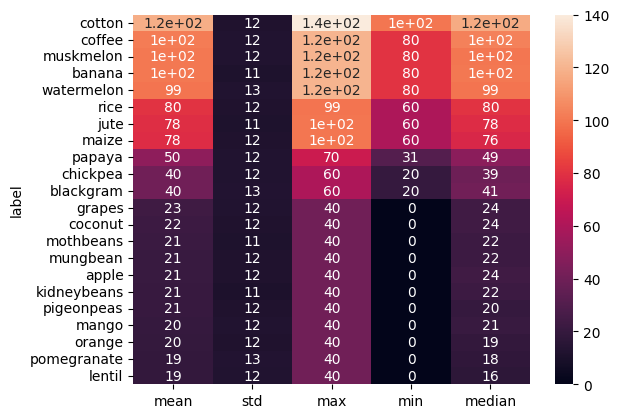

In [76]:
sns.heatmap(df.groupby('label')['N'].agg(['mean','std','max','min','median']).sort_values(by='mean',ascending=False),annot=True)

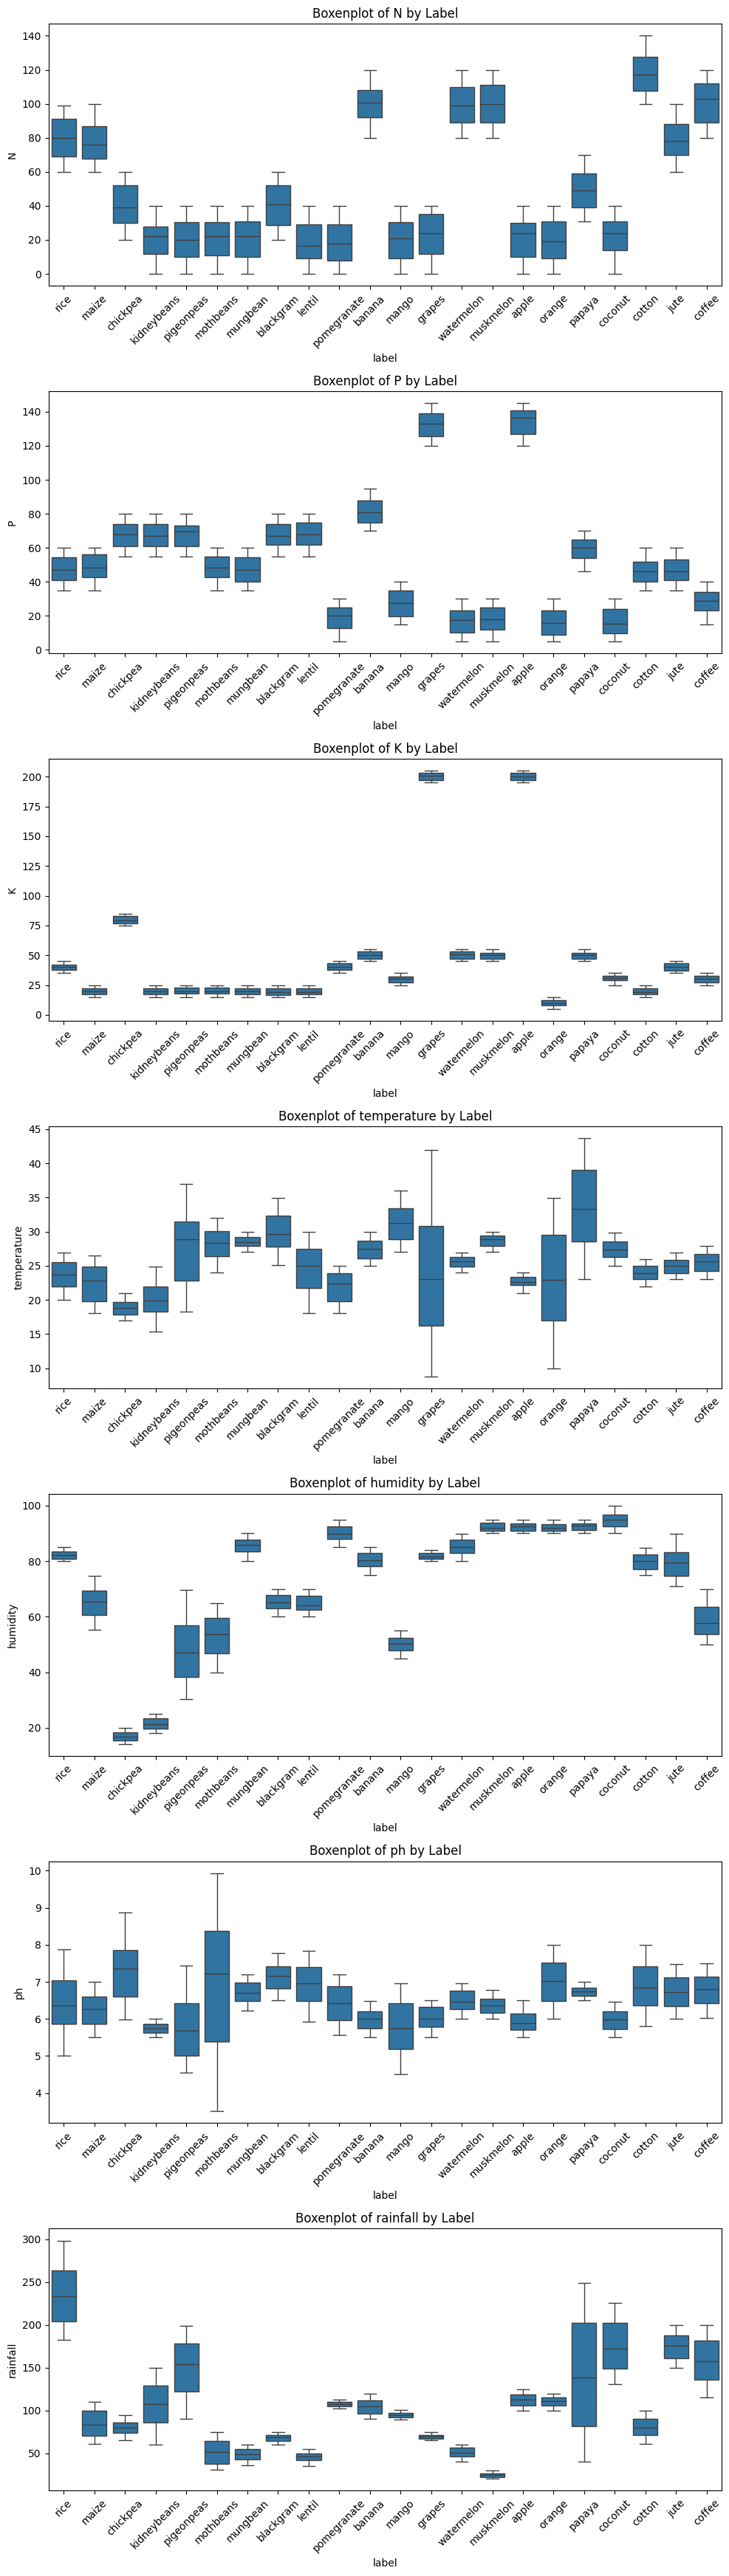

In [77]:
numerical_cols = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i])
    axes[i].set_title(f'Boxenplot of {col} by Label')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [78]:
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    print(f"Column '{col}': {len(outliers)} outliers found.")

Column 'N': 0 outliers found.
Column 'P': 138 outliers found.
Column 'K': 200 outliers found.
Column 'temperature': 86 outliers found.
Column 'humidity': 30 outliers found.
Column 'ph': 57 outliers found.
Column 'rainfall': 100 outliers found.


In [79]:
# creating the shallow copy so that we could retrive the changes back
X_copy = X.copy()

before transformation..


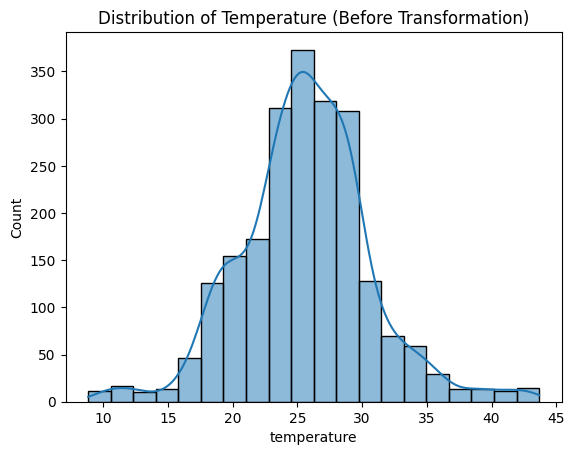


after transformation..


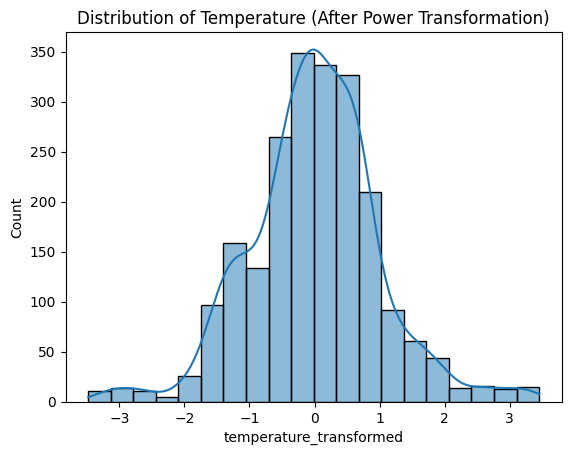

In [85]:
import numpy as np
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import seaborn as sns

print('before transformation..')
sns.histplot(X_copy['temperature'], bins=20, kde=True)
plt.title('Distribution of Temperature (Before Transformation)')
plt.show()

# Apply Power Transformation (Yeo-Johnson is suitable for data that can be zero or negative)
pt = PowerTransformer(method='yeo-johnson')
X_copy['temperature_transformed'] = pt.fit_transform(X_copy[['temperature']])
X_copy.drop('temperature',axis=1,inplace=True)

print('\nafter transformation..')
sns.histplot(X_copy['temperature_transformed'], bins=20, kde=True)
plt.title('Distribution of Temperature (After Power Transformation)')
plt.show()


Processing column: P


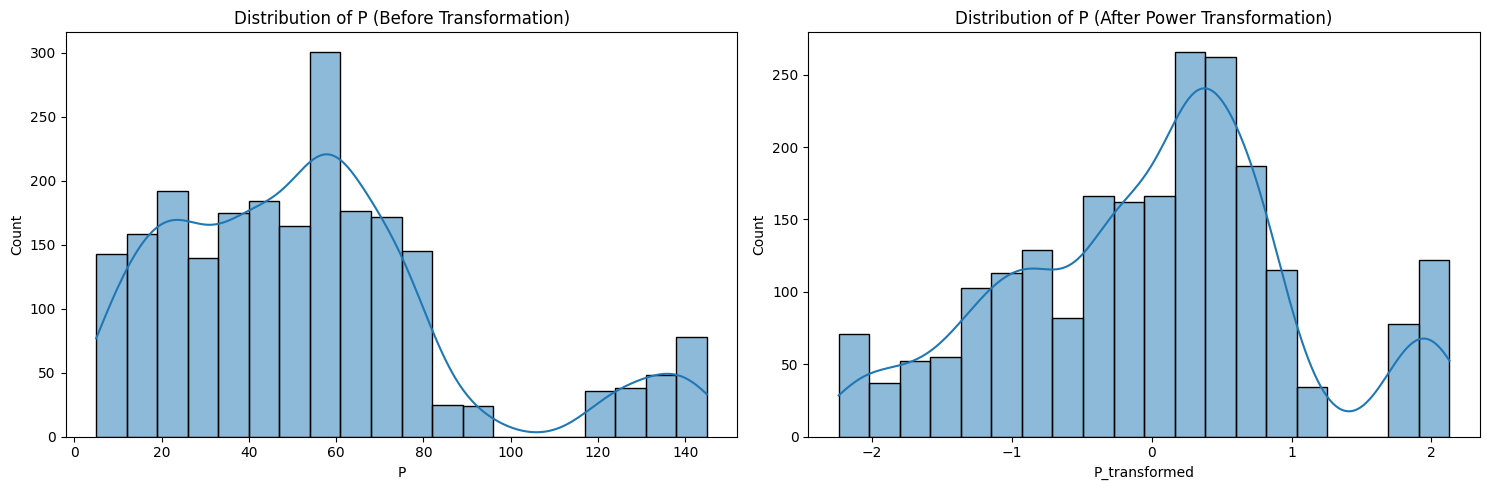


Processing column: K


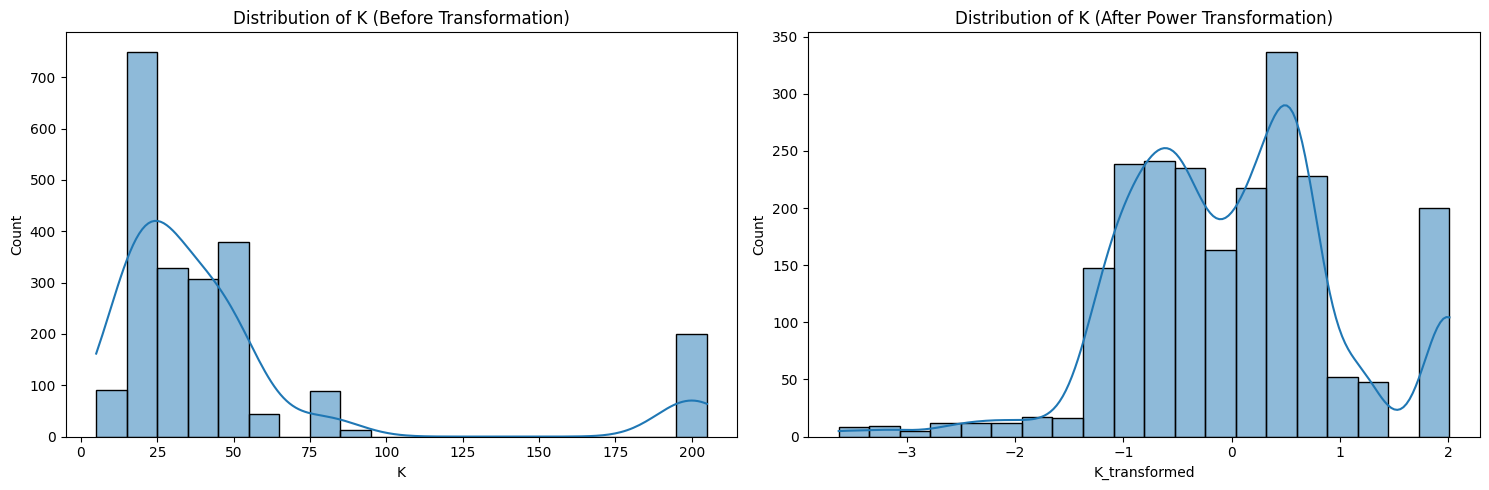


Processing column: humidity


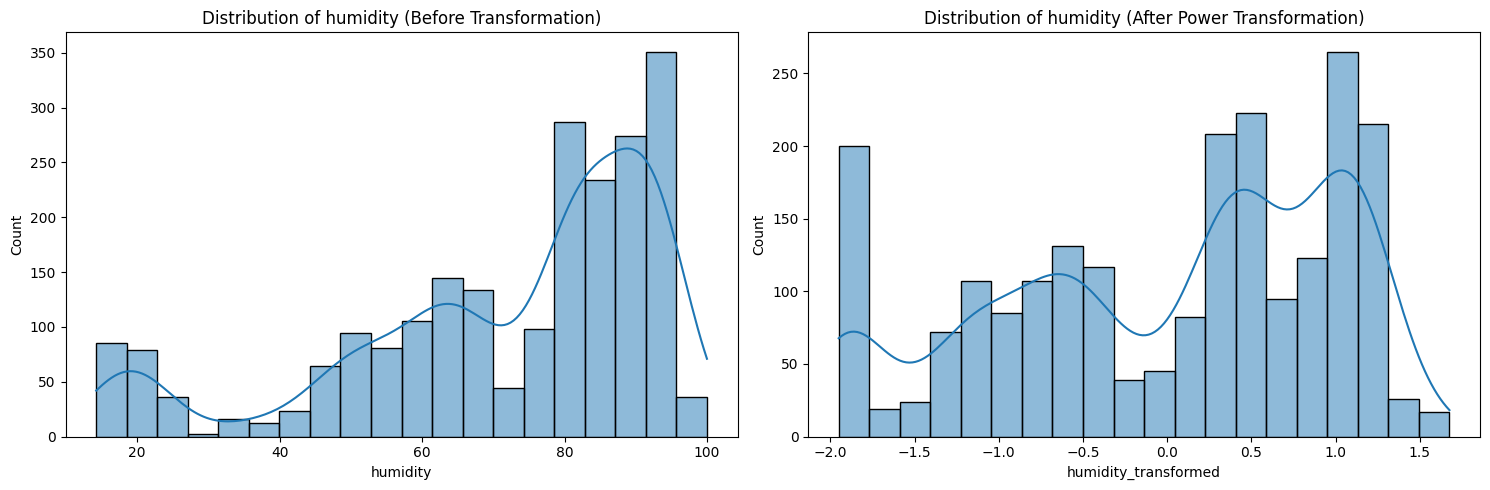


Processing column: ph


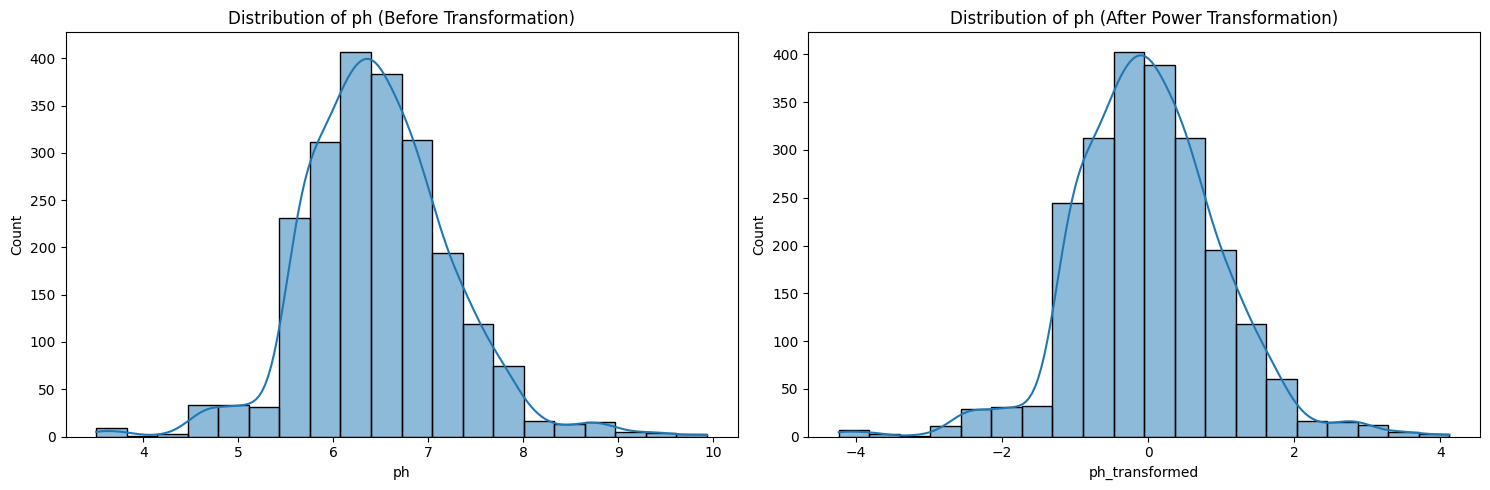


Processing column: rainfall


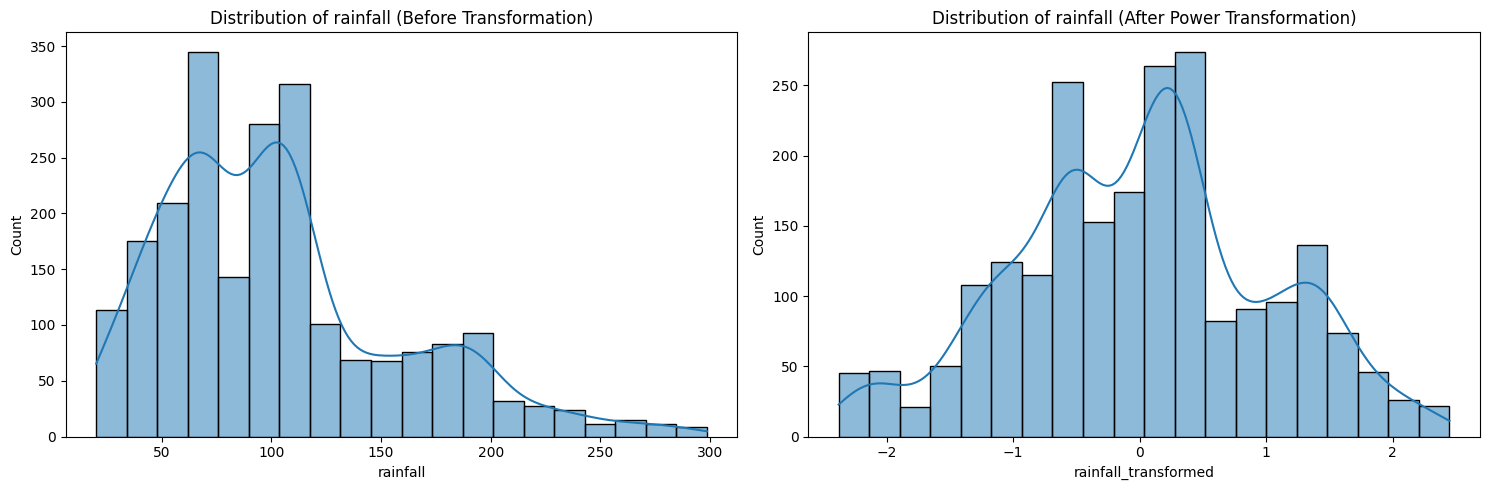

In [86]:
columns_to_transform = ['P', 'K', 'humidity', 'ph', 'rainfall']

for col in columns_to_transform:
    print(f"\nProcessing column: {col}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Before Transformation
    sns.histplot(X_copy[col], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col} (Before Transformation)')

    # Apply Power Transformation
    pt_col = PowerTransformer(method='yeo-johnson')
    X_copy[f'{col}_transformed'] = pt_col.fit_transform(X_copy[[col]])

    # After Transformation
    sns.histplot(X_copy[f'{col}_transformed'], bins=20, kde=True, ax=axes[1])
    axes[1].set_title(f'Distribution of {col} (After Power Transformation)')
    X_copy.drop(col,axis=1,inplace=True)

    plt.tight_layout()
    plt.show()

In [88]:
X_copy.rename(columns=lambda x: x.replace('_transformed', '') if '_transformed' in x else x, inplace=True)
print("Columns after renaming:")
print(X_copy.columns)

Columns after renaming:
Index(['N', 'temperature', 'P', 'K', 'humidity', 'ph', 'rainfall'], dtype='object')


In [90]:
X_copy

,N,temperature,P,K,humidity,ph,rainfall
0,90,-0.933044,-0.169541,0.430166,0.405334,0.066186,1.572569
1,85,-0.753510,0.328412,0.366477,0.300993,0.746037,1.815966
2,60,-0.506220,0.242156,0.460529,0.425326,1.728702,2.160912
3,74,0.184225,-0.424458,0.333035,0.291124,0.673719,1.970950
4,78,-1.084836,-0.169541,0.398834,0.380446,1.473277,2.150027
...,...,...,...,...,...,...,...
2195,107,0.239875,-0.463341,0.017445,-0.467769,0.420793,1.288484
2196,99,0.365711,-1.395097,-0.239543,-0.910316,-0.477363,0.615847
2197,118,-0.281689,-0.502927,-0.078439,-0.427420,-0.115679,1.234961
2198,117,0.141257,-0.543248,0.105607,-1.087767,0.393770,0.604262


3. label encoding the target

In [118]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(y)

X = X_copy

In [92]:
y

array([20, 20, 20, ...,  5,  5,  5])

4. train test split

In [93]:
X_train , X_test , y_train , y_test = train_test_split(X_copy,y,test_size=0.2,random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

5. model building

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [108]:
clf1 = LogisticRegression(penalty='l2',solver='newton-cg',n_jobs=-1,random_state=42)
clf1.fit(X_train,y_train)
y_pred = clf1.predict(X_test)

print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.90      0.90        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.83      0.87      0.85        23
           9       0.90      0.95      0.93        20
          10       0.79      1.00      0.88        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       0.96    

In [109]:
clf2 = DecisionTreeClassifier(random_state=42)
clf2.fit(X_train, y_train)
y_pred_dt = clf2.predict(X_test)

print("\nDecision Tree Classifier Results:")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Classifier Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00   

6. model exporting

In [133]:
import pickle
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# Define the numerical features that require Power Transformation
numerical_features_transform = ['P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Create a custom transformer to handle selective Power Transformation
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_features_transform, method='yeo-johnson'):
        self.numerical_features_transform = numerical_features_transform
        self.method = method
        self.transformers = {}
        self.columns_ = None

    def fit(self, X, y=None):
        self.columns_ = X.columns
        for col in self.numerical_features_transform:
            if col in X.columns:
                pt = PowerTransformer(method=self.method)
                pt.fit(X[[col]])
                self.transformers[col] = pt
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.numerical_features_transform:
            if col in X.columns and col in self.transformers:
                X_transformed[col] = self.transformers[col].transform(X[[col]])
        return X_transformed

# Re-define X_raw and y_raw from the original dataframe
X_raw_export = df.drop(columns='label')
y_raw_export = df['label']

# Label encode the target variable for the pipeline
le_export = LabelEncoder()
y_encoded_export = le_export.fit_transform(y_raw_export)

# Create the full pipeline with the custom preprocessor and Decision Tree Classifier
decision_tree_export_pipeline = Pipeline(steps=[
    ('custom_preprocessor', CustomPreprocessor(numerical_features_transform)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the pipeline on the full raw data (or training split if preferred, but for export, often trained on all available)
decision_tree_export_pipeline.fit(X_raw_export, y_encoded_export)

# Export the pipeline as a pickle file
pickle_filename = 'decision_tree_crop_recommender_pipeline.pkl'
with open(pickle_filename, 'wb') as file:
    pickle.dump(decision_tree_export_pipeline, file)

print(f"Decision Tree Pipeline exported successfully as '{pickle_filename}'")


Decision Tree Pipeline exported successfully as 'decision_tree_crop_recommender_pipeline.pkl'

--- Demonstrating loaded pipeline ---
New raw data:
        N   P   K  temperature   humidity        ph    rainfall
2195  107  34  32    26.774637  66.413269  6.780064  177.774507
Predicted crop label: coffee
Actual crop label for this data: rice


In [9]:
pickle.dump(df,open('df.pkl','wb'))

7. Building the gradio app

In [12]:
import gradio as gr
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer

class CustomPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_features_transform, method='yeo-johnson'):
        self.numerical_features_transform = numerical_features_transform
        self.method = method
        self.transformers = {}
        self.columns_ = None

    def fit(self, X, y=None):
        self.columns_ = X.columns
        for col in self.numerical_features_transform:
            if col in X.columns:
                pt = PowerTransformer(method=self.method)
                pt.fit(X[[col]])
                self.transformers[col] = pt
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.numerical_features_transform:
            if col in X.columns and col in self.transformers:
                X_transformed[col] = self.transformers[col].transform(X[[col]])
        return X_transformed

Pipe = pickle.load(open('/content/decision_tree_crop_recommender_pipeline.pkl','rb'))

df = pickle.load(open('/content/df.pkl','rb'))

le = LabelEncoder()
le.fit(df['label'])

def get_output(N,P,K,temperature,humidity,ph,rainfall):
  test_df = pd.DataFrame({
      'N':[N],
      'P':[P],
      'K':[K],
      'temperature':[temperature],
      'humidity':[humidity],
      'ph':[ph],
      'rainfall':[rainfall]
  })
  output = Pipe.predict(test_df)[0]
  # Now 'le' is properly fitted and can inverse_transform the encoded prediction
  output = le.inverse_transform([output])[0]

  return f'you can grow {output} as per your soil details 👍'

input_list = [
    gr.Slider(0,140,label='Nitrogen'),
    gr.Slider(5,205,label='Phosphorus'),
    gr.Slider(10,20,label='Potassium'),
    gr.Slider(0,60,label='Temperature'),
    gr.Slider(0,100,label='Humidity'),
    gr.Slider(0,14,label='pH'),
    gr.Slider(0,200,label='Rainfall')
]

iface = gr.Interface(
    fn = get_output,
    inputs = input_list,
    outputs = 'text'
)

iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f46de3895b06a105c3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
